In [1]:
# ==========================================
# 1. PREPARACIÓ DE L'ENTORN MODERN
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

using ITensors
using ITensorMPS
using Plots

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


El hamiltoniano del sistema viene dado por la expresión:
$$    H=J\sum_{i=1}^{N-1}\left[\frac{1}{2}\left(S_i^+ S^-_{i+1}+S^-_iS^+_{i+1} \right) +\Delta S_i^zS_{i+1}^z\right]+\sum_{i=1}^N h_i S_i^z=\sum_{i=1}^{N-1}\left(J\left[\frac{1}{2}\left(S_i^+ S^-_{i+1}+S^-_iS^+_{i+1} \right) +\Delta S_i^zS_{i+1}^z\right]+ h_i S_i^z\right)+h_N S_N^z=\sum_{i=1}^N H_i
$$ donde $J$ representa la constante de acoplamiento, $\Delta$ es el parámetro de anisotropía y $h_i$ es el campo magnético local. Se debe precisar que los términos de interacción local se definen como $H_i = J \left[ \frac{1}{2} ( S_i^+ S^-_{i+1} + S^-_i S^+_{i+1} ) + \Delta S_i^z S_{i+1}^z \right] + h_i S_i^z$ para $i=1,2,\dots,N$, mientras que el término del último sitio es simplemente $H_N = h_N S_N^z$.

In [2]:
# Parámetros
  N = 100                      # Número de sitios=espines
  t_total = 10.0               # Tiempo total de simulación
  δt = 0.1                     # Paso de tiempo de simulación
  steps = Int(t_total / δt)    # Número total de pasos de simulación
  J = 1.0                      # Constante de acoplamiento
  Δ = 0.5                      # Parámetro de anisotropía

0.5

In [3]:
# Definición de los N espines del sistema (con conservación de QNs)
  sites = siteinds("S=1/2", N; conserve_qns=true)

100-element Vector{Index{Vector{Pair{QN, Int64}}}}:
 (dim=2|id=240|"S=1/2,Site,n=1") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=508|"S=1/2,Site,n=2") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=813|"S=1/2,Site,n=3") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=766|"S=1/2,Site,n=4") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=219|"S=1/2,Site,n=5") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=732|"S=1/2,Site,n=6") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=361|"S=1/2,Site,n=7") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=554|"S=1/2,Site,n=8") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=483|"S=1/2,Site,n=9") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=255|"S=1/2,Site,n=10") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=343|"S=1/2,Site,n=11") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=270|"S=1/2,Site,n=12") <Out>
 1: QN("Sz",1) => 1
 2: QN

In [4]:
# Estado inicial: "Pulso de calor" en el centro
# Todos los espines "Down" excepto el central que está "Up"
  state = fill("Dn", N)
  state[N ÷ 2] = "Up"
  psi = MPS(sites, state)

100-element MPS:
 ((dim=2|id=240|"S=1/2,Site,n=1") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=1|id=95|"Link,l=1") <In>
 1: QN("Sz",-1) => 1)
 ((dim=1|id=95|"Link,l=1") <Out>
 1: QN("Sz",-1) => 1, (dim=2|id=508|"S=1/2,Site,n=2") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=1|id=171|"Link,l=2") <In>
 1: QN("Sz",-2) => 1)
 ((dim=1|id=171|"Link,l=2") <Out>
 1: QN("Sz",-2) => 1, (dim=2|id=813|"S=1/2,Site,n=3") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=1|id=305|"Link,l=3") <In>
 1: QN("Sz",-3) => 1)
 ((dim=1|id=305|"Link,l=3") <Out>
 1: QN("Sz",-3) => 1, (dim=2|id=766|"S=1/2,Site,n=4") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=1|id=533|"Link,l=4") <In>
 1: QN("Sz",-4) => 1)
 ((dim=1|id=533|"Link,l=4") <Out>
 1: QN("Sz",-4) => 1, (dim=2|id=219|"S=1/2,Site,n=5") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=1|id=620|"Link,l=5") <In>
 1: QN("Sz",-5) => 1)
 ((dim=1|id=620|"Link,l=5") <Out>
 1: QN("Sz",-5) => 1, (dim=2|id=732|"S=1/2,Site,n=6") <Out>


In [5]:
# Puertas para TEBD (Trotter gates)
  gates = ITensor[]
  for j in 1:(N - 1)
    s1 = sites[j]
    s2 = sites[j+1]
    # Hamiltoniano local H = J*0.5*(S+S- + S-S+) + J*Δ*SzSz
    hj = J * 0.5 * (op("S+", s1) * op("S-", s2) + op("S-", s1) * op("S+", s2)) +
         J * Δ * op("Sz", s1) * op("Sz", s2)
    Gj = exp(-im * (δt / 2) * hj) # Exponencial para evolución temporal
    push!(gates, Gj)
  end

In [6]:
# Añadimos las puertas en orden inverso para simetría de Trotter (2º orden)
  append!(gates, reverse(gates))

198-element Vector{ITensor}:
 ITensor ord=4
Dim 1: (dim=2|id=240|"S=1/2,Site,n=1")' <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
Dim 2: (dim=2|id=508|"S=1/2,Site,n=2")' <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
Dim 3: (dim=2|id=240|"S=1/2,Site,n=1") <In>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
Dim 4: (dim=2|id=508|"S=1/2,Site,n=2") <In>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
NDTensors.BlockSparse{ComplexF64, Vector{ComplexF64}, 4}
 2×2×2×2
Block(2, 2, 2, 2)
 [2:2, 2:2, 2:2, 2:2]
[:, :, 1, 1] =
 0.9999804688135782 - 0.006249959309975305im

Block(2, 1, 2, 1)
 [2:2, 1:1, 2:2, 1:1]
[:, :, 1, 1] =
 0.9996679911924586 + 0.006248006299413418im

Block(1, 2, 2, 1)
 [1:1, 2:2, 2:2, 1:1]
[:, :, 1, 1] =
 0.000156232707322295 - 0.02499690768591266im

Block(2, 1, 1, 2)
 [2:2, 1:1, 1:1, 2:2]
[:, :, 1, 1] =
 0.000156232707322295 - 0.02499690768591266im

Block(1, 2, 1, 2)
 [1:1, 2:2, 1:1, 2:2]
[:, :, 1, 1] =
 0.9996679911924585 + 0.006248006299413416im

Block(1, 1, 1, 1)
 [1:1, 1:1, 1:1, 1:1]

In [7]:
# Evolución temporal y recogida de datos
  # Matriz para guardar Sz en cada sitio y cada tiempo
  data = zeros(steps + 1, N)

101×100 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

In [8]:
println("Iniciando evolución temporal...")
  for n in 1:(steps + 1)
    # Medimos Sz en todos los sitios
    data[n, :] = expect(psi, "Sz")
    
    # Aplicamos las puertas (paso de tiempo TEBD)
    psi = apply(gates, psi; cutoff=1E-8)
    normalize!(psi)
    
    if n % 20 == 0
      println("Paso $n de $steps...")
    end
  end

Iniciando evolución temporal...
Paso 20 de 100...
Paso 40 de 100...
Paso 60 de 100...
Paso 80 de 100...
Paso 100 de 100...


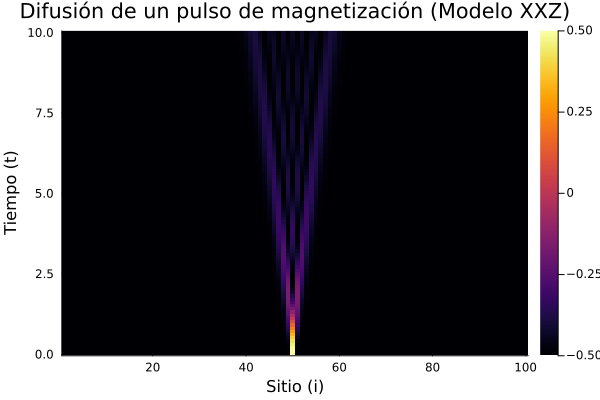

In [9]:
# Generación de la Gráfica
  # Usamos un mapa de colores tipo 'inferno' o 'hot' para la analogía del calor
  p = heatmap(1:N, 0:δt:t_total, data,
              title="Difusión de un pulso de magnetización (Modelo XXZ)",
              xlabel="Sitio (i)",
              ylabel="Tiempo (t)",
              color=:inferno,
              clabel="<Sz>")
  
  display(p)

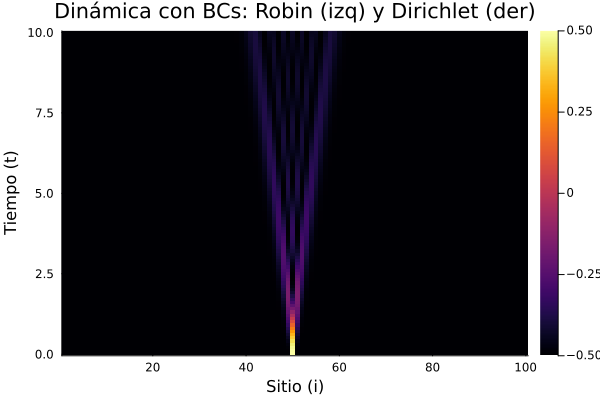

In [10]:
using ITensors
using Plots

let
  # 1. Parámetros
  N = 100
  t_total = 10.0
  δt = 0.1
  steps = Int(t_total / δt)
  J = 1.0
  Δ = 0.5
  
  # Parámetros de Frontera
  h_ext = 0.2        # Robin (Ambiente en sitio 1)
  J_robin = 0.5 * J  # Conductividad en el borde 1-2
  h_fixed = 5.0      # Dirichlet (Anclaje en sitio N)

  # 2. Setup
  sites = siteinds("S=1/2", N; conserve_qns=true)
  
  # 3. Estado inicial: Pulso en el centro
  state = fill("Dn", N)
  state[N ÷ 2] = "Up"
  psi = MPS(sites, state)

  # 4. Construcción de puertas TEBD con BCs
  gates = ITensor[]
  
  for j in 1:(N - 1)
    s1 = sites[j]
    s2 = sites[j+1]
    
    # Definimos el Hamiltoniano local de la puerta hj
    hj = ITensor() 

    if j == 1
        # --- PUERTA 1: Incluye la condición de ROBIN ---
        # Intercambio debilitado + campo ambiental en sitio 1
        hj = J_robin * 0.5 * (op("S+", s1) * op("S-", s2) + op("S-", s1) * op("S+", s2)) +
             J_robin * Δ * op("Sz", s1) * op("Sz", s2) +
             h_ext * op("Sz", s1) * op("Id", s2) # Campo en el borde izquierdo

    elseif j == N - 1
        # --- PUERTA N-1: Incluye la condición de DIRICHLET ---
        # Intercambio normal + campo fuerte en sitio N
        hj = J * 0.5 * (op("S+", s1) * op("S-", s2) + op("S-", s1) * op("S+", s2)) +
             J * Δ * op("Sz", s1) * op("Sz", s2) +
             h_fixed * op("Id", s1) * op("Sz", s2) # Campo de anclaje en el borde derecho
    else
        # --- PUERTAS DEL BULK (Normales) ---
        hj = J * 0.5 * (op("S+", s1) * op("S-", s2) + op("S-", s1) * op("S+", s2)) +
             J * Δ * op("Sz", s1) * op("Sz", s2)
    end

    # Exponencial para evolución temporal exp(-i * δt/2 * hj)
    Gj = exp(-im * (δt / 2) * hj)
    push!(gates, Gj)
  end
  
  # Simetría de Trotter (2º orden)
  append!(gates, reverse(gates))

  # 5. Evolución
  data = zeros(steps + 1, N)
  
  for n in 1:(steps + 1)
    data[n, :] = expect(psi, "Sz")
    psi = apply(gates, psi; cutoff=1E-8)
    normalize!(psi)
  end

  # 6. Gráfica
  heatmap(1:N, 0:δt:t_total, data,
          title="Dinámica con BCs: Robin (izq) y Dirichlet (der)",
          xlabel="Sitio (i)", ylabel="Tiempo (t)",
          color=:inferno)
end

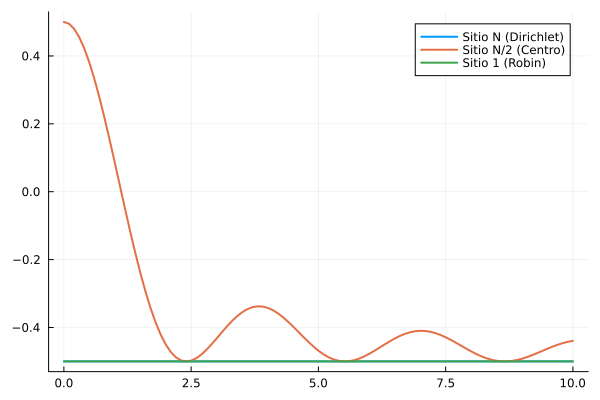

In [13]:
# Ejemplo de lo que verías si graficas sitios específicos
plot(0:δt:t_total, data[:, N], label="Sitio N (Dirichlet)", lw=2)
plot!(0:δt:t_total, data[:, N÷2], label="Sitio N/2 (Centro)", lw=2)
plot!(0:δt:t_total, data[:, 1], label="Sitio 1 (Robin)", lw=2)

In [ ]:
#La creación de los sites, la construcción del MPO y la solución por TEBD
#se puede integrar en una única función, en los que Delta es la anisotropía y h_profile 
#es un array que contiene un perfil de campo magnético
# Ambosentran como parámetros para realizar múltiples experimentos
# Devuelve como resultado la magnetización
function solve_TEBD(N, J,Δ, h_profile)
    sites = siteinds("S=1/2", N; conserve_qns=true)
    os = OpSum()
    for j in 1:(N - 1)
        os += 0.5*J, "S+", j, "S-", j + 1
        os += 0.5*J, "S-", j, "S+", j + 1
        os += J*Δ, "Sz", j, "Sz", j + 1
    end
    for j in 1:N
        os += h_profile[j], "Sz", j
    end
    H = MPO(os, sites)
    
    # Estado inicial (media magnetización para Sz=0)
    state = [isodd(n) ? "Up" : "Dn" for n in 1:N]
    psi0 = randomMPS(sites, state; linkdims=10)
    
    sweeps = Sweeps(10)
    setmaxdim!(sweeps, 10, 20, 50, 100)
    setcutoff!(sweeps, 1E-10)
    
    energy, psi = dmrg(H, psi0, sweeps)
    return expect(psi, "Sz")
end